# Exercise 04 — CNN on the Diabetes Dataset (Tabular → 1D Sequence)


In [1]:
# --- 0. Install required libraries (skip if already installed) ---
# In Jupyter/Colab, uncomment and run the line below once:
# %pip install -q numpy pandas scikit-learn matplotlib torch tensorflow

import importlib.util

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "torch": "torch",
    "tensorflow": "tensorflow",
}
missing_pip_names = [pip_name for mod_name, pip_name in required.items()
                      if importlib.util.find_spec(mod_name) is None]

if missing_pip_names:
    print("Missing packages:", missing_pip_names)
    print("Run this in a cell:  %pip install -q " + " ".join(missing_pip_names))
else:
    print("All required libraries are already installed.")


All required libraries are already installed.


## 1. Load and preprocess the data

Eight features, exactly as the slide describes: `gender, age, hypertension, heart_disease, smoking_history, bmi, HbA1c_level, blood_glucose_level` → predict `diabetes`.

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

DATA_PATH = "../data/diabetes_prediction_dataset.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
# For a fast, self-contained teaching exercise we sample a subset.
# Increase N_SAMPLES if you want to train on more data (all three
# implementations will just take longer).
N_SAMPLES = 6000
df = df.sample(N_SAMPLES, random_state=42).reset_index(drop=True)

# Encode the two categorical columns as integer codes so we keep
# exactly eight numeric "sequence positions", as the slide specifies.
df['gender'] = df['gender'].astype('category').cat.codes
df['smoking_history'] = df['smoking_history'].astype('category').cat.codes

FEATURE_COLS = ['gender', 'age', 'hypertension', 'heart_disease',
                'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
TARGET_COL = 'diabetes'

X = df[FEATURE_COLS].values.astype(np.float64)
y = df[TARGET_COL].values.astype(np.float64)

# Standardize features (zero mean, unit variance) -- important for
# convolution/dense layers to train in a reasonable number of epochs.
mu, sigma = X.mean(axis=0), X.std(axis=0) + 1e-8
X = (X - mu) / sigma

# Train / test split (80 / 20)
n_train = int(0.8 * len(X))
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Positive rate (train):", y_train.mean().round(3))


X_train: (4800, 8)  X_test: (1200, 8)
Positive rate (train): 0.08


Reshape into `(batch, channels=1, length=8)` — a 1D sequence with a single input channel, matching `Conv1D(x; k, b)` from the slides.

In [4]:
X_train_seq = X_train[:, None, :]   # (N, 1, 8)
X_test_seq = X_test[:, None, :]     # (N, 1, 8)
X_train_seq.shape, X_test_seq.shape


((4800, 1, 8), (1200, 1, 8))

## 2. NumPy from scratch

Following the slide *"CNN From Scratch"*:

$$z_i = \sum_{j=0}^{m-1} k_j x_{i+j} + b$$

We implement `Conv1D`, `ReLU`, `MaxPool1D`, `Flatten` and `Dense` as small classes, each with a `forward` and a `backward` (manual gradient + manual SGD update), matching:

$$\theta \leftarrow \theta - \eta \nabla_\theta L$$


In [5]:
class Conv1D:
    """1D convolution layer: z_i = sum_j k_j * x_{i+j} + b (per output channel)."""
    def __init__(self, in_channels, out_channels, kernel_size, seed=0):
        rng = np.random.default_rng(seed)
        scale = np.sqrt(2.0 / (in_channels * kernel_size))
        self.W = rng.normal(0, scale, size=(out_channels, in_channels, kernel_size))
        self.b = np.zeros(out_channels)

    def forward(self, x):
        # x: (batch, in_channels, length)
        batch, in_c, length = x.shape
        out_c, _, k = self.W.shape
        out_len = length - k + 1
        out = np.zeros((batch, out_c, out_len))
        for i in range(out_len):
            window = x[:, :, i:i + k]                              # (batch, in_c, k)
            out[:, :, i] = np.tensordot(window, self.W, axes=([1, 2], [1, 2])) + self.b
        self.cache = (x, out_len)
        return out

    def backward(self, dout, lr):
        x, out_len = self.cache
        batch = x.shape[0]
        out_c, in_c, k = self.W.shape
        dW = np.zeros_like(self.W)
        db = np.zeros_like(self.b)
        dx = np.zeros_like(x)
        for i in range(out_len):
            window = x[:, :, i:i + k]
            dW += np.einsum('bo,bik->oik', dout[:, :, i], window)
            db += dout[:, :, i].sum(axis=0)
            dx[:, :, i:i + k] += np.einsum('bo,oik->bik', dout[:, :, i], self.W)
        self.W -= lr * dW / batch
        self.b -= lr * db / batch
        return dx


class ReLU:
    """h = ReLU(z) = max(0, z)"""
    def forward(self, x):
        self.mask = x > 0
        return x * self.mask

    def backward(self, dout, lr=None):
        return dout * self.mask


class MaxPool1D:
    """p_i = max(x_i, x_{i+1}, ...) over a non-overlapping window of `size`."""
    def __init__(self, size=2):
        self.size = size

    def forward(self, x):
        batch, c, length = x.shape
        out_len = length // self.size
        out = np.zeros((batch, c, out_len))
        self.mask = np.zeros_like(x)
        for i in range(out_len):
            seg = x[:, :, i * self.size:(i + 1) * self.size]
            idx = np.argmax(seg, axis=2)
            out[:, :, i] = np.max(seg, axis=2)
            b_idx, c_idx = np.indices((batch, c))
            self.mask[b_idx, c_idx, i * self.size + idx] = 1
        return out

    def backward(self, dout, lr=None):
        batch, c, out_len = dout.shape
        dx = np.zeros_like(self.mask)
        for i in range(out_len):
            seg_mask = self.mask[:, :, i * self.size:(i + 1) * self.size]
            dx[:, :, i * self.size:(i + 1) * self.size] = seg_mask * dout[:, :, i:i + 1]
        return dx


class Flatten:
    def forward(self, x):
        self.shape = x.shape
        return x.reshape(x.shape[0], -1)

    def backward(self, dout, lr=None):
        return dout.reshape(self.shape)


class Dense:
    """H = XW + b (the same linear layer as a dense network)."""
    def __init__(self, in_dim, out_dim, seed=1):
        rng = np.random.default_rng(seed)
        self.W = rng.normal(0, np.sqrt(2.0 / in_dim), size=(in_dim, out_dim))
        self.b = np.zeros(out_dim)

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b

    def backward(self, dout, lr):
        dW = self.x.T @ dout / self.x.shape[0]
        db = dout.mean(axis=0)
        dx = dout @ self.W.T
        self.W -= lr * dW
        self.b -= lr * db
        return dx


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


Architecture: `Conv1D(1→16, k=3) → ReLU → Conv1D(16→8, k=3) → ReLU → MaxPool(2) → Flatten → Dense(→1) → Sigmoid`, matching the slide's `8 → 16 → 16 → 8 → 1` sizing idea.

In [6]:
conv1_np = Conv1D(in_channels=1, out_channels=16, kernel_size=3, seed=0)
relu1_np = ReLU()
conv2_np = Conv1D(in_channels=16, out_channels=8, kernel_size=3, seed=1)
relu2_np = ReLU()
pool_np = MaxPool1D(size=2)
flat_np = Flatten()

# Infer the flattened dimension with a dry run.
_out = conv1_np.forward(X_train_seq[:2])
_out = relu1_np.forward(_out)
_out = conv2_np.forward(_out)
_out = relu2_np.forward(_out)
_out = pool_np.forward(_out)
_out = flat_np.forward(_out)
flat_dim = _out.shape[1]
print("Flattened feature size:", flat_dim)

dense_np = Dense(flat_dim, 1, seed=2)


Flattened feature size: 16


In [7]:
def forward_pass(x):
    z1 = conv1_np.forward(x)
    a1 = relu1_np.forward(z1)
    z2 = conv2_np.forward(a1)
    a2 = relu2_np.forward(z2)
    p = pool_np.forward(a2)
    f = flat_np.forward(p)
    logits = dense_np.forward(f)
    return sigmoid(logits)


def backward_pass(preds, yb, lr):
    dlogits = (preds - yb)                 # d(BCE)/d(logits) for sigmoid output
    df_ = dense_np.backward(dlogits, lr)
    dp = flat_np.backward(df_, lr)
    da2 = pool_np.backward(dp, lr)
    dz2 = relu2_np.backward(da2, lr)
    da1 = conv2_np.backward(dz2, lr)
    dz1 = relu1_np.backward(da1, lr)
    conv1_np.backward(dz1, lr)


LR = 0.05
EPOCHS = 40
BATCH_SIZE = 64
n = X_train_seq.shape[0]
eps = 1e-8

history_np = []
for epoch in range(EPOCHS):
    perm = np.random.permutation(n)
    Xs, ys = X_train_seq[perm], y_train[perm]
    epoch_losses = []
    for i in range(0, n, BATCH_SIZE):
        xb = Xs[i:i + BATCH_SIZE]
        yb = ys[i:i + BATCH_SIZE].reshape(-1, 1)

        preds = forward_pass(xb)
        loss = -np.mean(yb * np.log(preds + eps) + (1 - yb) * np.log(1 - preds + eps))
        epoch_losses.append(loss)

        backward_pass(preds, yb, LR)

    history_np.append(np.mean(epoch_losses))
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:2d}  loss {history_np[-1]:.4f}")


epoch  0  loss 0.2931
epoch  5  loss 0.1306
epoch 10  loss 0.1215
epoch 15  loss 0.1181
epoch 20  loss 0.1174
epoch 25  loss 0.1173
epoch 30  loss 0.1146
epoch 35  loss 0.1125
epoch 39  loss 0.1121


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

preds_test_np = forward_pass(X_test_seq).flatten()
labels_np = (preds_test_np > 0.5).astype(int)

results_np = {
    "accuracy": accuracy_score(y_test, labels_np),
    "precision": precision_score(y_test, labels_np, zero_division=0),
    "recall": recall_score(y_test, labels_np, zero_division=0),
    "f1": f1_score(y_test, labels_np, zero_division=0),
}
print("NumPy-from-scratch test metrics:", {k: round(v, 4) for k, v in results_np.items()})


NumPy-from-scratch test metrics: {'accuracy': 0.9508, 'precision': 0.8983, 'recall': 0.5, 'f1': 0.6424}


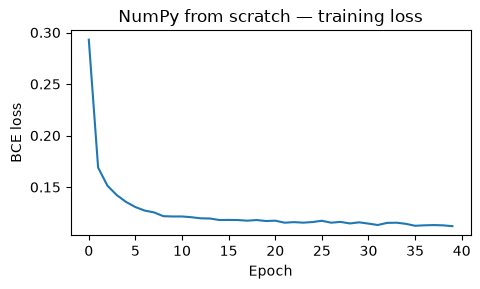

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.plot(history_np)
plt.title("NumPy from scratch — training loss")
plt.xlabel("Epoch"); plt.ylabel("BCE loss")
plt.tight_layout()
plt.show()


## 3. PyTorch

Same architecture, expressed with `nn.Conv1d`, `nn.ReLU`, `nn.MaxPool1d`, `nn.Linear`, trained with autograd + an optimizer instead of manual gradients — exactly the "From Scratch to PyTorch" slide.

> If PyTorch is not installed in your environment, run `pip install torch` first.


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)

class DiabetesCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(16, 8, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.flatten = nn.Flatten()
        self.fc = nn.LazyLinear(1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc(x)
        return self.sigmoid(x)


model_pt = DiabetesCNN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.01)

X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

EPOCHS = 40
BATCH_SIZE = 64
n = X_train_t.shape[0]
history_pt = []

for epoch in range(EPOCHS):
    perm = torch.randperm(n)
    epoch_losses = []
    for i in range(0, n, BATCH_SIZE):
        batch_idx = perm[i:i + BATCH_SIZE]
        xb, yb = X_train_t[batch_idx], y_train_t[batch_idx]

        optimizer.zero_grad()
        preds = model_pt(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    history_pt.append(sum(epoch_losses) / len(epoch_losses))
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:2d}  loss {history_pt[-1]:.4f}")


epoch  0  loss 0.2605
epoch  5  loss 0.1000
epoch 10  loss 0.0940
epoch 15  loss 0.0894
epoch 20  loss 0.0888
epoch 25  loss 0.0874
epoch 30  loss 0.0834
epoch 35  loss 0.0853
epoch 39  loss 0.0823


In [11]:
model_pt.eval()
with torch.no_grad():
    preds_test_pt = model_pt(X_test_t).numpy().flatten()
labels_pt = (preds_test_pt > 0.5).astype(int)

results_pt = {
    "accuracy": accuracy_score(y_test, labels_pt),
    "precision": precision_score(y_test, labels_pt, zero_division=0),
    "recall": recall_score(y_test, labels_pt, zero_division=0),
    "f1": f1_score(y_test, labels_pt, zero_division=0),
}
print("PyTorch test metrics:", {k: round(v, 4) for k, v in results_pt.items()})


PyTorch test metrics: {'accuracy': 0.9583, 'precision': 0.9, 'recall': 0.5943, 'f1': 0.7159}


## 4. TensorFlow / Keras

Same architecture again, expressed with `tf.keras.layers.Conv1D`, trained with `model.fit()` (automatic differentiation under the hood) — the "From Scratch to TensorFlow" slide.

> If TensorFlow is not installed in your environment, run `pip install tensorflow` first.


In [12]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install tensorflow

In [13]:
import tensorflow as tf

tf.random.set_seed(42)

model_tf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(8, 1)),
    tf.keras.layers.Conv1D(filters=16, kernel_size=3, activation="relu"),
    tf.keras.layers.Conv1D(filters=8, kernel_size=3, activation="relu"),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model_tf.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                  loss="binary_crossentropy", metrics=["accuracy"])
model_tf.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 16)          │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 4, 8)           │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 473 (1.85 KB)

 Trainable params: 473 (1.85 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# TensorFlow's Conv1D expects channels-last: (batch, length, channels)
X_train_tf = np.transpose(X_train_seq, (0, 2, 1))
X_test_tf = np.transpose(X_test_seq, (0, 2, 1))

history_tf = model_tf.fit(
    X_train_tf, y_train,
    epochs=40, batch_size=64, verbose=0,
)
print("final training loss:", history_tf.history["loss"][-1])


final training loss: 0.08715449273586273


In [15]:
preds_test_tf = model_tf.predict(X_test_tf, verbose=0).flatten()
labels_tf = (preds_test_tf > 0.5).astype(int)

results_tf = {
    "accuracy": accuracy_score(y_test, labels_tf),
    "precision": precision_score(y_test, labels_tf, zero_division=0),
    "recall": recall_score(y_test, labels_tf, zero_division=0),
    "f1": f1_score(y_test, labels_tf, zero_division=0),
}
print("TensorFlow test metrics:", {k: round(v, 4) for k, v in results_tf.items()})


TensorFlow test metrics: {'accuracy': 0.9583, 'precision': 0.8684, 'recall': 0.6226, 'f1': 0.7253}


## 5. Compare the three implementations

Per the slide *"What Stays the Same?"* — same data, split, preprocessing, model idea, loss, and evaluation metrics across all three. Only the **implementation layer** changes (per *"What Changes?"*).

In [16]:
comparison = pd.DataFrame(
    [results_np, results_pt, results_tf],
    index=["NumPy (from scratch)", "PyTorch", "TensorFlow/Keras"],
)
comparison.round(4)


,accuracy,precision,recall,f1
NumPy (from scratch),0.9508,0.8983,0.5000,0.6424
PyTorch,0.9583,0.9000,0.5943,0.7159
TensorFlow/Keras,0.9583,0.8684,0.6226,0.7253


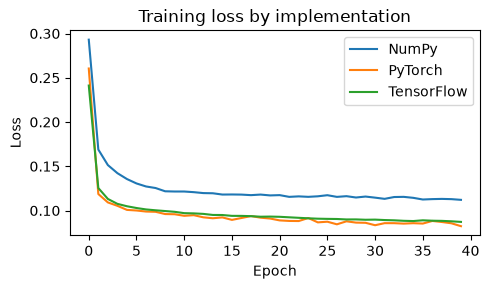

In [17]:
plt.figure(figsize=(5, 3))
plt.plot(history_np, label="NumPy")
plt.plot(history_pt, label="PyTorch")
plt.plot(history_tf.history["loss"], label="TensorFlow")
plt.title("Training loss by implementation")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Discussion

- **Same mathematical model, three implementations.** All three follow
  `X → Conv1D → ReLU → Conv1D → ReLU → Pool → Flatten → Dense → ŷ`.
  NumPy computes every gradient by hand; PyTorch uses autograd; TensorFlow uses
  `GradientTape`/`fit()` — the *math* is identical, the *plumbing* differs.
- **Modeling caveat.** As the slides stress, these eight tabular columns are not
  spatially related the way pixels are, so a 1D CNN here is a **pedagogical
  exercise** in composing `Conv → ReLU → Pool → Dense`, not evidence that CNNs
  are the right tool for tabular data. A plain dense network or gradient-boosted
  trees would likely do at least as well on this dataset.
- Fill in your own observations here after running all three cells above
  (e.g. did accuracy/F1 differ meaningfully? did one framework train faster or
  converge to a lower loss?).


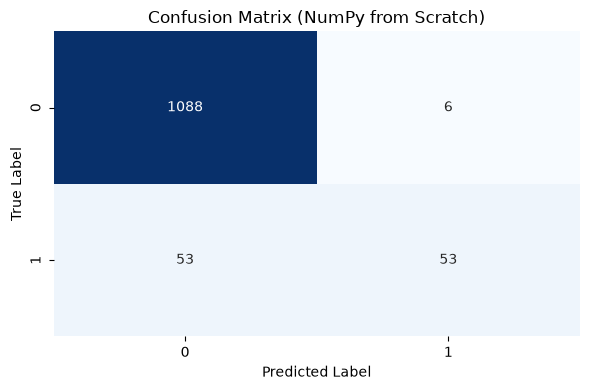

In [18]:
# 7. Confusion Matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, labels_np) # Using NumPy scratch predictions

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (NumPy from Scratch)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
